## HW 02: Echo Cancellation

1. `ref.wav`, `pri.wav`, `pri2.wav`를 불러온다.
2. 128-tap NLMS 필터를 $w_0=1$, $w_1, \ldots, w_{127}=0$으로 초기화하고 여러 하이퍼파라미터를 실험한다.
3. 필터링 결과인 `err.wav`, `err2.wav`를 들어 본 뒤 최종 하이퍼파라미터를 선택한다.

제출 기한: 9/23 (수)

### 1. 입력 음성 확인

#### 1.1 실행 환경

In [1]:
import sys

print(sys.executable)
print("Python version:", sys.version)

/Users/yejin/Development/Yejin-02/26-Fall-Adap/.venv/bin/python
Python version: 3.9.6 (default, Oct 17 2025, 17:15:53) 
[Clang 17.0.0 (clang-1700.4.4.1)]


#### 1.2 `ref`, `pri1`, `pri2` 들어 보기

In [2]:
from pathlib import Path

import soundfile as sf
from IPython.display import Audio, display

paths = { "ref": Path("ref.wav"),
        "pri1": Path("pri.wav"),
        "pri2": Path("pri2.wav"), }
datas = {}

for name, file_path in paths.items():
    print("\n=== ", name, " ===")
    display(Audio(filename=file_path, normalize=False))

    data, samplerate = sf.read(file_path)
    
    print(f"Data shape: {data.shape}")
    print(f"Sample rate: {samplerate} Hz")
    print(f"Duration: {data.shape[0] / samplerate:.2f} seconds")
    print(f"Data type: {data.dtype}")
    
    datas[name] = data

SAMPLERATE = samplerate


===  ref  ===


Data shape: (18800,)
Sample rate: 8000 Hz
Duration: 2.35 seconds
Data type: float64

===  pri1  ===


Data shape: (18800,)
Sample rate: 8000 Hz
Duration: 2.35 seconds
Data type: float64

===  pri2  ===


Data shape: (18800,)
Sample rate: 8000 Hz
Duration: 2.35 seconds
Data type: float64


세 파일은 모두 길이 2.35초, 1채널, 8 kHz이며 `float64`로 불러왔다.

- `ref.wav`: 비교적 깨끗한 남성 화자 음성
- `pri.wav`: `ref.wav`가 RIR을 거쳐 마이크에 들어온 에코 신호
- `pri2.wav`: `pri.wav`에 후반부 여성 화자 음성이 더해진 double-talk 신호

#### 1.3 Double-talk 구간 확인

First nonzero sample: 12800
Start time: 1.600 s


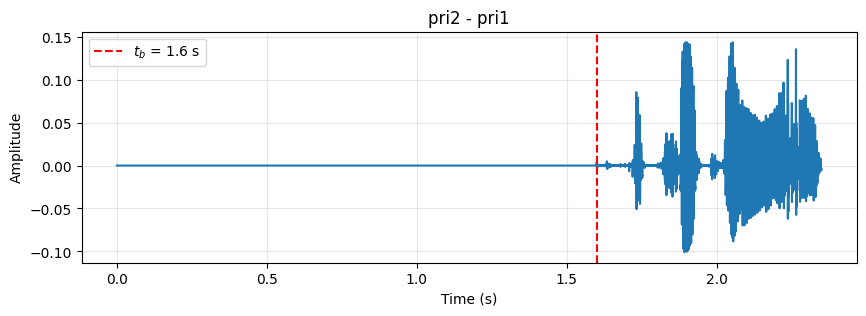

In [3]:
import matplotlib.pyplot as plt
import numpy as np

diff_pri1_pri2 = datas["pri2"] - datas["pri1"]
nonzero_samples = np.flatnonzero(diff_pri1_pri2 != 0)

tb_sample = nonzero_samples[0]
tb = tb_sample / SAMPLERATE

print(f"First nonzero sample: {tb_sample}")
print(f"Start time: {tb:.3f} s")

time_sec = np.arange(len(diff_pri1_pri2)) / SAMPLERATE
plt.figure(figsize=(10, 3))
plt.plot(time_sec, diff_pri1_pri2)
plt.axvline(tb, color="red", linestyle="--", label=f"$t_b$ = {tb:.1f} s")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("pri2 - pri1")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

display(Audio(data=diff_pri1_pri2, rate=SAMPLERATE, normalize=False))

#### 1.4 기준 신호와 마이크 신호의 차이 확인

In [4]:
print("\n=== diff ===")
diff_ref_pri1 = datas["pri1"]-datas["ref"]
display(Audio(data=diff_ref_pri1, rate=SAMPLERATE, normalize=False))

diff_ref_pri2 = datas["pri2"]-datas["ref"]
display(Audio(data=diff_ref_pri2, rate=SAMPLERATE, normalize=False))


=== diff ===


처음에는 `ref`가 스피커에서 마이크로 전달되는 동안 크게 달라지지 않을 것이라고 생각했다. 하지만 `pri1 - ref`와 `pri2 - ref`를 직접 들어 보니 두 신호의 차이가 생각보다 컸다.

따라서 `ref`를 그대로 빼는 대신, 적응 필터로 마이크에 들어온 에코를 추정할 필요가 있다. 먼저 파형과 STFT를 이용해 세 신호의 차이를 확인했다.

#### 1.5 파형과 STFT 비교

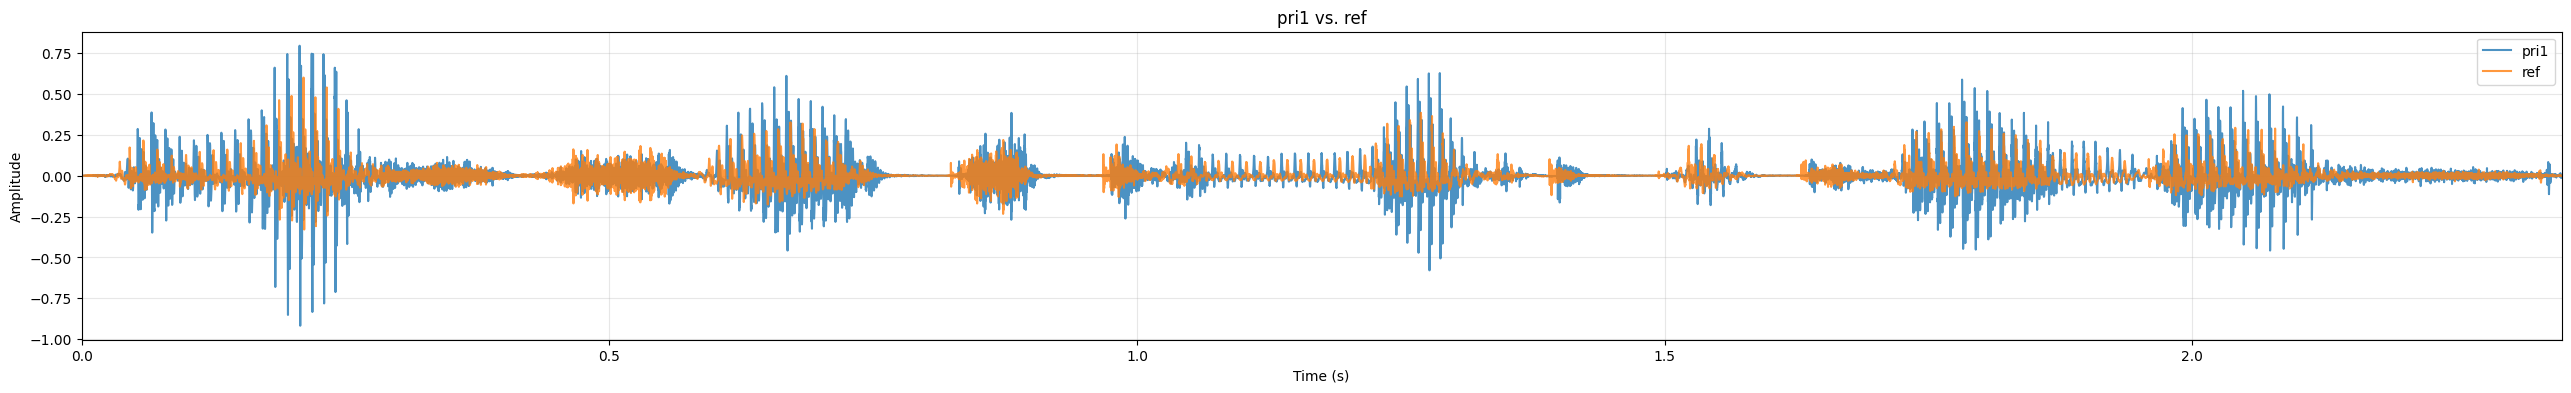

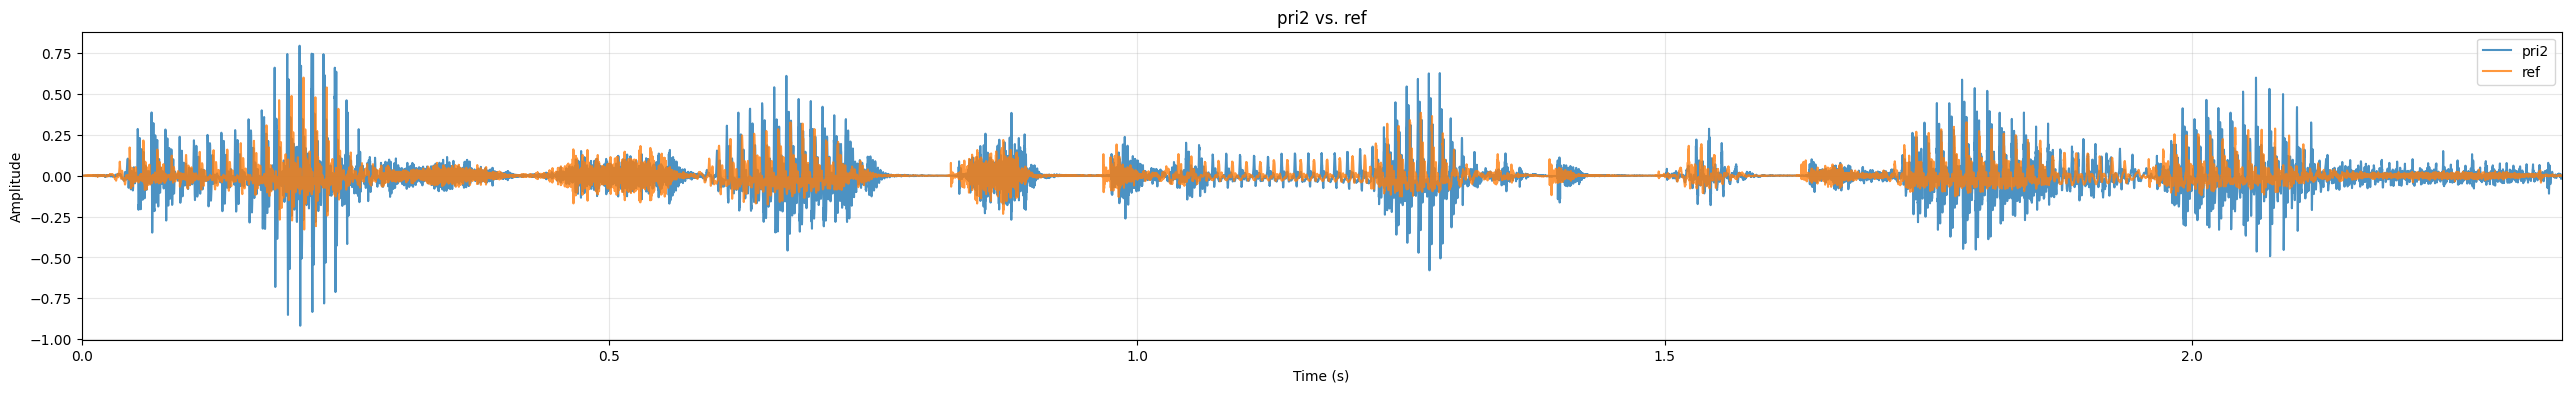

In [5]:
import matplotlib.pyplot as plt
import numpy as np

time_sec = np.arange(len(datas["ref"])) / SAMPLERATE

plt.figure(figsize=(32, 4))
plt.plot(time_sec, datas["pri1"], label="pri1", alpha=0.8)
plt.plot(time_sec, datas["ref"], label="ref", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("pri1 vs. ref")
plt.xlim(0, time_sec[-1])
plt.grid(alpha=0.3)
plt.legend()

plt.figure(figsize=(32, 4))
plt.plot(time_sec, datas["pri2"], label="pri2", alpha=0.8)
plt.plot(time_sec, datas["ref"], label="ref", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("pri2 vs. ref")
plt.xlim(0, time_sec[-1])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

전체적인 발화 시점은 비슷하지만, `pri1`과 `pri2`는 `ref`보다 진폭이 크고 신호가 시간축으로 더 퍼져 있다.

또한 `pri2`에는 `pri1`에 없는 여성 화자 음성이 포함되어 있어 후반부 파형에서 차이가 나타난다.

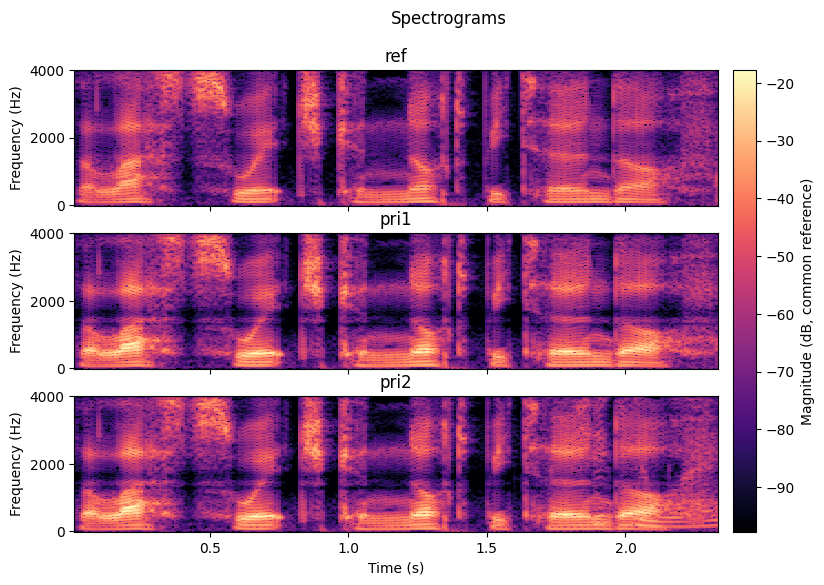

In [6]:
from scipy.signal import stft

signals_for_stft = {
    "ref": datas["ref"],
    "pri1": datas["pri1"],
    "pri2": datas["pri2"],
}

spectrograms = {}
for name, signal in signals_for_stft.items():
    freq, time, spectrum = stft(
        signal,
        fs=SAMPLERATE,
        window="hann",
        nperseg=256,       # 32 ms at 8 kHz
        noverlap=192,      # 75% overlap
        boundary=None,
        padded=False,
    )
    spectrograms[name] = (freq, time, 20 * np.log10(np.maximum(np.abs(spectrum), 1e-10)))

global_max_db = max(spec_db.max() for _, _, spec_db in spectrograms.values())

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, sharey=True)
for ax, (name, (freq, time, spec_db)) in zip(axes, spectrograms.items()):
    mesh = ax.pcolormesh(
        time, freq, spec_db,
        shading="auto", cmap="magma",
        vmin=global_max_db - 80, vmax=global_max_db,
    )
    ax.set_title(name)
    ax.set_ylabel("Frequency (Hz)")

axes[-1].set_xlabel("Time (s)")
fig.colorbar(mesh, ax=axes, label="Magnitude (dB, common reference)", pad=0.02)
fig.suptitle("Spectrograms")
plt.show()

STFT에서도 `ref`와 마이크 신호 사이의 차이를 확인할 수 있었다. `pri2 - pri1`은 1.6초 전까지 0이며, 이후의 차이는 추가된 여성 화자 음성에 해당한다.

### 2. NLMS 필터 실험

#### 2.1 탭 계수 업데이트

현재 탭 계수로 에코 추정값 $y_n$을 구하고, 마이크 신호 $d_n$과의 차이를 오차 $e_n$으로 계산한다.

$$e_n=d_n-y_n$$

계수는 오차가 작아지는 방향으로 다음과 같이 업데이트한다.

$$\mathbf{w}_{n+1}=\mathbf{w}_n+\frac{\mu e_n}{\lVert\mathbf{u}_n\rVert^2+\delta}\mathbf{u}_n$$

In [7]:
import numpy as np


# weight update
def update_tap_line(tap_line, u_n, d_n, mu, delta):
    y_n = np.dot(tap_line, u_n) # n번째 출력 = tap_line과 u_n의 내적
    e_n = d_n - y_n # n번째 오차 = 원하는 n번째 출력 - 실제 n번째 출력

    power_norm = np.dot(u_n, u_n) + delta
    scale = mu * e_n / power_norm
    new_tap_line = tap_line + scale * u_n

    ''' print(f"\ny_n = u_n @ tap_line = {u_n} @ {tap_line} = {y_n}, \ne_n = d_n - y_n = {d_n} - {y_n} = {e_n}, power_norm = {power_norm}", end="\n\t=> ")

    if scale == 0:
        print("No update needed (scale = 0)")
    else:
        print(f"new_tap_line = {tap_line} + {scale} * {u_n} = {new_tap_line}") '''

    return new_tap_line, y_n, e_n

#### 2.2 128-tap 필터 구성

각 시점에서 최근 `ref` 샘플 128개를 입력 벡터로 만들고, 위의 업데이트를 샘플마다 반복한다.

- 시작 부분에서 부족한 샘플은 0으로 채운다.
- 첫 번째 탭은 1, 나머지 탭은 0으로 초기화한다.
- `output`은 추정한 에코이고, `error`는 마이크 신호에서 추정 에코를 뺀 결과이다.

In [8]:
TAP = 128

# filter 출력
def filtering(mu, delta, desired_signal, input_signal):
    # init
    tap_line = np.zeros(TAP, dtype=np.float64)
    tap_line[0] = 1.0

    output = np.zeros_like(desired_signal)
    error = np.zeros_like(desired_signal)

    pad_input = np.pad(input_signal, (len(tap_line) - 1, 0), 'constant')

    # update를 반복
    for n in range(len(tap_line), len(pad_input) + 1):
        u_n = pad_input[n - len(tap_line):n][::-1]

        tap_line, y_n, e_n = update_tap_line(tap_line, u_n, desired_signal[n - len(tap_line)], mu, delta)
        output[n-len(tap_line)] = y_n
        error[n-len(tap_line)] = e_n

    return output, error

#### 2.3 $\mu$, $\delta$에 따른 결과 비교

`(ref, pri1)`과 `(ref, pri2)`에 여러 $\mu$, $\delta$ 조합을 적용하고 결과를 비교한다. RMS와 SNR을 참고하되, 최종 선택에서는 실제 청취 결과도 함께 고려한다.


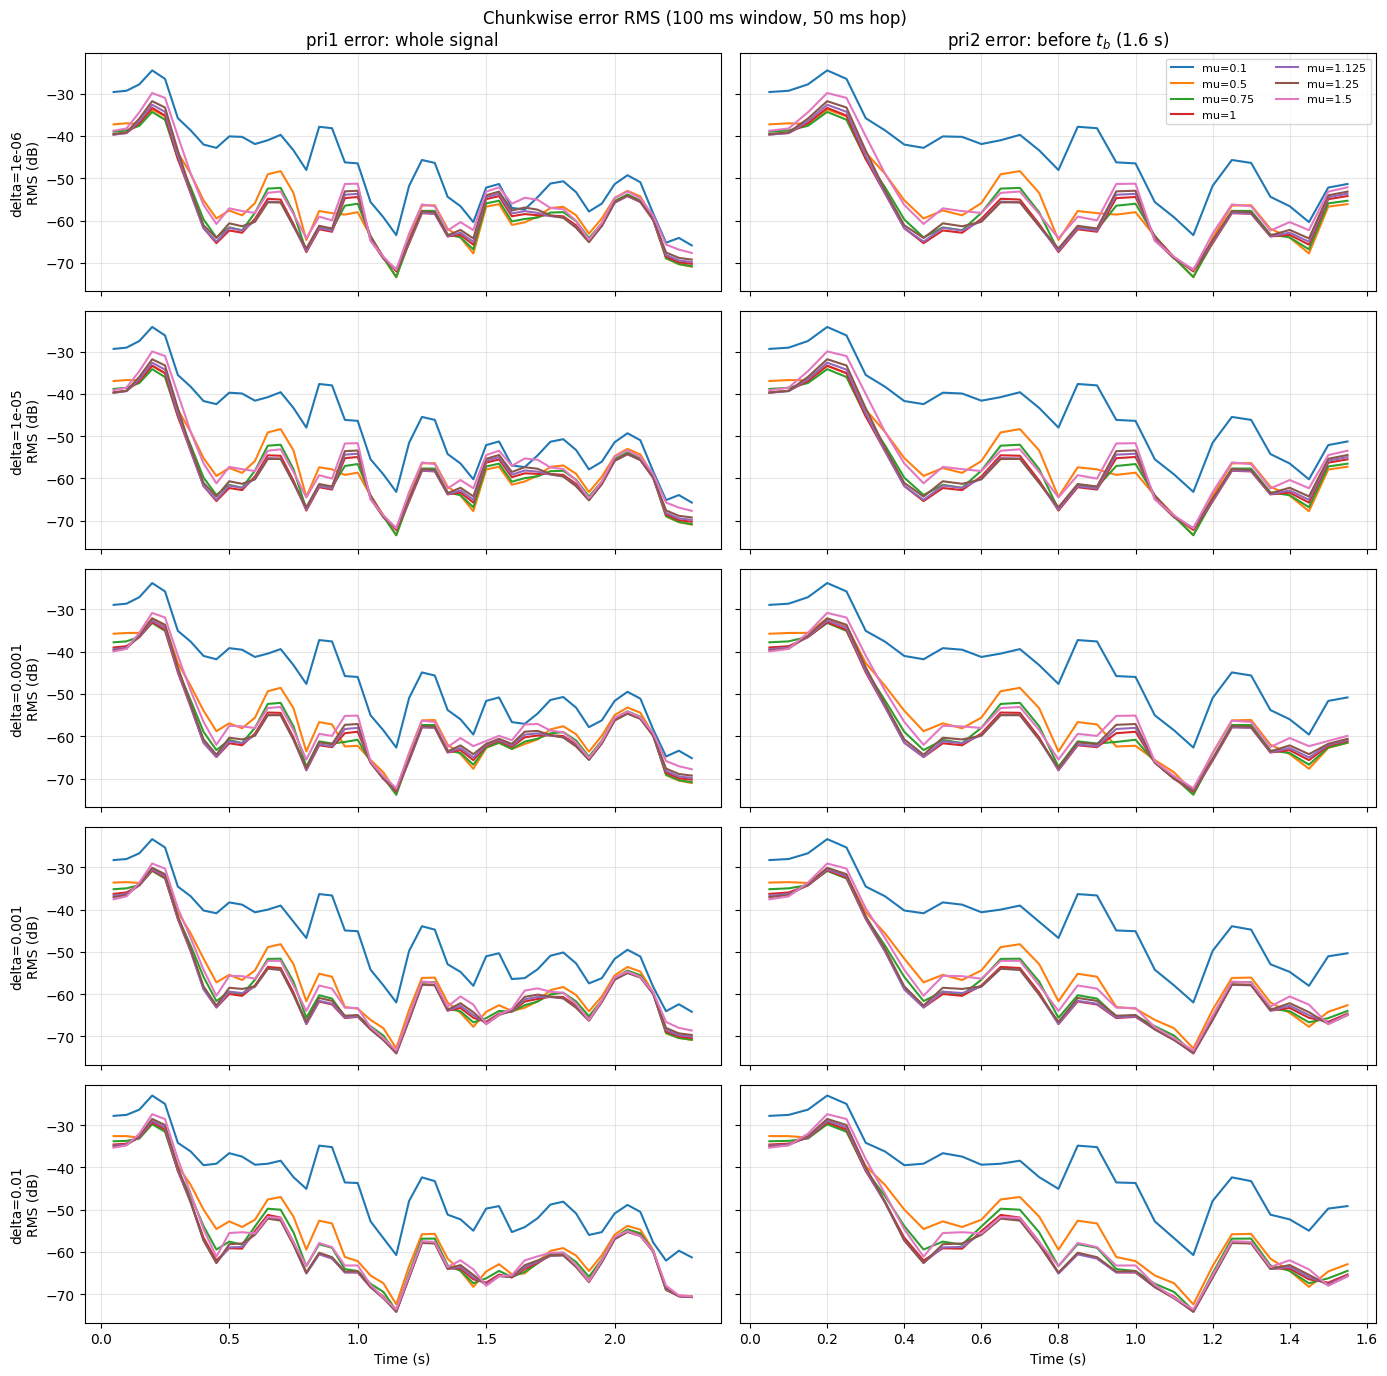

In [9]:
from IPython.display import HTML, Audio, display

DELTA = [ 1e-6, 1e-5, 1e-4, 1e-3, 1e-2 ]
MU = [ 0.1, 0.5, 0.75, 1, 1.125, 1.25, 1.5 ]
CHUNK_SIZE = int(0.1 * SAMPLERATE) # 100 ms
HOP_SIZE = int(0.05 * SAMPLERATE) # 50 ms

def rms(signal):
    return np.sqrt(np.mean(signal ** 2))


def chunkwise_rms(signal):
    starts = np.arange(0, len(signal) - CHUNK_SIZE + 1, HOP_SIZE)
    values = np.array([rms(signal[start:start + CHUNK_SIZE]) for start in starts])
    times = (starts + CHUNK_SIZE / 2) / SAMPLERATE
    return times, values


def snr_db(reference, estimate):
    return 10 * np.log10(
        np.sum(reference ** 2)
        / (np.sum((estimate - reference) ** 2) + 1e-12)
    )


FILTER_RESULTS = {}
for pri in (1, 2):
    for delta in DELTA:
        for mu in MU:
            _, err = filtering(
                mu=mu,
                delta=delta,
                desired_signal=datas[f"pri{pri}"],
                input_signal=datas["ref"],
            )
            FILTER_RESULTS[(pri, delta, mu)] = err


def make_audio_grid(pri):
    cells = []

    # 왼쪽 위 빈 칸
    cells.append('<div class="grid-header">δ ＼ μ</div>')

    # μ 열 제목
    for mu in MU:
        cells.append(
            f'<div class="grid-header">μ = {mu:g}</div>'
        )

    # 각 δ 행
    for delta in DELTA:
        cells.append(
            f'<div class="grid-header">δ = {delta:g}</div>'
        )

        for mu in MU:
            err = FILTER_RESULTS[(pri, delta, mu)]
            peak = np.max(np.abs(err))

            if pri == 1:
                metric = f"RMS: {rms(err):.5f}<br>Peak: {peak:.4f}"
            else:
                rms_before = rms(err[:tb_sample])
                snr_after = snr_db(
                    diff_pri1_pri2[tb_sample:],
                    err[tb_sample:],
                )
                metric = (
                    f"RMS before t<sub>b</sub>: {rms_before:.5f}<br>"
                    f"SNR after t<sub>b</sub>: {snr_after:.2f} dB<br>"
                    f"Peak: {peak:.4f}"
                )

            # 자동 음량 정규화를 끈 오디오 플레이어
            player = Audio(
                data=err,
                rate=SAMPLERATE,
                normalize=False,
            )._repr_html_()

            cells.append(f"""
                <div class="audio-card">
                    <div class="metric">
                        {metric}
                    </div>
                    {player}
                </div>
            """)

    column_count = len(MU) + 1

    return HTML(f"""
    <style>
        .nlms-wrapper {{
            overflow-x: auto;
            margin: 12px 0 28px 0;
        }}

        .nlms-grid {{
            display: grid;
            grid-template-columns:
                110px repeat({len(MU)}, minmax(220px, 1fr));
            gap: 8px;
            min-width: {110 + 230 * len(MU)}px;
            align-items: stretch;
        }}

        .grid-header {{
            display: flex;
            justify-content: center;
            align-items: center;
            padding: 10px;
            border-radius: 6px;
            background: var(--vscode-editorWidget-background, #252526);
            font-weight: 600;
            text-align: center;
        }}

        .audio-card {{
            padding: 10px;
            border: 1px solid
                var(--vscode-widget-border, #555);
            border-radius: 8px;
            background: var(--vscode-editor-background, #1e1e1e);
        }}

        .audio-card audio {{
            width: 100%;
            margin-top: 8px;
        }}

        .metric {{
            min-height: 54px;
            font-family: monospace;
            font-size: 12px;
            line-height: 1.45;
        }}
    </style>

    <details open>
        <summary>
            <strong>PRI {pri}</strong>
        </summary>

        <div class="nlms-wrapper">
            <div
                class="nlms-grid"
                style="grid-template-columns:
                    110px repeat({column_count - 1},
                    minmax(220px, 1fr));"
            >
                {''.join(cells)}
            </div>
        </div>
    </details>
    """)


def plot_chunkwise_rms():
    fig, axes = plt.subplots(
        len(DELTA), 2, figsize=(14, 14),
        sharex="col", sharey=True,
    )

    for row, delta in enumerate(DELTA):
        for mu in MU:
            err1 = FILTER_RESULTS[(1, delta, mu)]
            time1, rms1 = chunkwise_rms(err1)
            axes[row, 0].plot(time1, 20 * np.log10(rms1 + 1e-12), label=f"mu={mu:g}")

            err2_before = FILTER_RESULTS[(2, delta, mu)][:tb_sample]
            time2, rms2 = chunkwise_rms(err2_before)
            axes[row, 1].plot(time2, 20 * np.log10(rms2 + 1e-12), label=f"mu={mu:g}")

        axes[row, 0].set_ylabel(f"delta={delta:g}\nRMS (dB)")
        axes[row, 0].grid(alpha=0.3)
        axes[row, 1].grid(alpha=0.3)

    axes[0, 0].set_title("pri1 error: whole signal")
    axes[0, 1].set_title(f"pri2 error: before $t_b$ ({tb:.1f} s)")
    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")
    axes[0, 1].legend(loc="upper right", ncol=2, fontsize=8)
    fig.suptitle("Chunkwise error RMS (100 ms window, 50 ms hop)")
    fig.tight_layout()
    plt.show()


plot_chunkwise_rms()
display(make_audio_grid(1))
display(make_audio_grid(2))

### 3. 최종 파라미터와 출력

- `pri1`: 전체 오차 RMS가 작고, 청취했을 때 잔여 에코가 적었던 $\mu=0.75$, $\delta=10^{-6}$을 선택했다.
- `pri2`: double-talk 이전의 에코 제거 정도와 이후 여성 화자의 보존 정도를 함께 고려하여 $\mu=0.5$, $\delta=10^{-4}$을 선택했다.

`pri2`에서는 double-talk 중에도 계수가 계속 업데이트되므로 여성 화자의 음성이 일부 왜곡될 수 있다. 이는 별도의 double-talk 검출을 사용하지 않은 기본 NLMS 필터의 한계로 보았다.

In [10]:
BEST_PRI1 = {
    "mu": 0.75,
    "delta": 1e-6,
}

BEST_PRI2 = {
    "mu": 0.5,
    "delta": 1e-4,
}

_, err = filtering(
    mu=BEST_PRI1["mu"],
    delta=BEST_PRI1["delta"],
    desired_signal=datas["pri1"],
    input_signal=datas["ref"],
)

_, err2 = filtering(
    mu=BEST_PRI2["mu"],
    delta=BEST_PRI2["delta"],
    desired_signal=datas["pri2"],
    input_signal=datas["ref"],
)

sf.write("err.wav", err, SAMPLERATE, subtype="PCM_16")
sf.write("err2.wav", err2, SAMPLERATE, subtype="PCM_16")

display(Audio(filename="err.wav", normalize=False))
display(Audio(filename="err2.wav", normalize=False))